In [1]:
import os
import pandas as pd

# 1. Inject your Kaggle Token
%env KAGGLE_API_TOKEN=KGAT_4344e5c3203d76bd8f2962bcd2c4072a

# 2. Download the Predictive Maintenance Dataset
!kaggle datasets download -d shivamb/machine-predictive-maintenance-classification

# 3. Unzip the file
!unzip -o -q machine-predictive-maintenance-classification.zip

# 4. Load the data into a Pandas DataFrame (This is your "pipeline" start)
df = pd.read_csv('predictive_maintenance.csv')

print(f"Success! We have {len(df)} machine sensor records loaded.")
print("Here is a sneak peek at the data:")
display(df.head())

env: KAGGLE_API_TOKEN=KGAT_4344e5c3203d76bd8f2962bcd2c4072a
Dataset URL: https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification
License(s): CC0-1.0
100% 137k/137k [00:00<00:00, 621kB/s]

Success! We have 10000 machine sensor records loaded.
Here is a sneak peek at the data:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

print("Step 1: Engineering feature extraction pipeline...")

X = df.drop(['UDI', 'Product ID', 'Target', 'Failure Type'], axis=1)
y = df['Target'] # 0 = No Failure, 1 = Machine Failure

# --- THE FIX IS HERE ---
# Cleaning column names using Regex to remove [ ] and < so XGBoost doesn't crash
X.columns = X.columns.str.replace(r'[\[\]<]', '', regex=True)

# Machine 'Type' is text (L, M, H). AI needs numbers, so we encode it.
le = LabelEncoder()
X['Type'] = le.fit_transform(X['Type'])

# 2. Split data: 80% to train the AI, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Model
print("Step 2: Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds) * 100

# 4. Train the XGBoost Model
print("Step 3: Training XGBoost Model...")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds) * 100

print("\n--- FINAL RESULTS ---")
print(f"Random Forest Accuracy: {rf_acc:.2f}%")
print(f"XGBoost Accuracy:     {xgb_acc:.2f}%")

Step 1: Engineering feature extraction pipeline...
Step 2: Training Random Forest Model...
Step 3: Training XGBoost Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:55:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- FINAL RESULTS ---
Random Forest Accuracy: 98.40%
XGBoost Accuracy:     98.50%


Generating Feature Importance Graph...


/tmp/ipykernel_11166/726790289.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


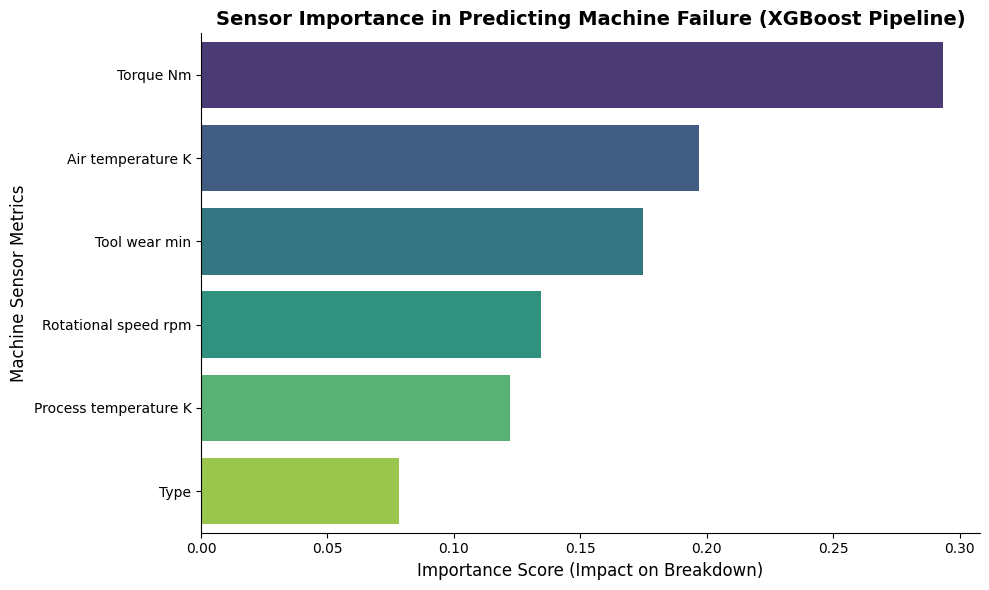

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating Feature Importance Graph...")

# Extract what the XGBoost model learned
importances = xgb_model.feature_importances_
features = X.columns

# Create a clean table of the data
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Draw the graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Sensor Importance in Predicting Machine Failure (XGBoost Pipeline)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Impact on Breakdown)', fontsize=12)
plt.ylabel('Machine Sensor Metrics', fontsize=12)

# Make it look professional
sns.despine()
plt.tight_layout()
plt.show()